# HW2 - Phase 2
## Parsa Daghigh
## Closed-loop design

In [93]:
from google.colab import drive

drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


## Imports

In [110]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import mannwhitneyu, ttest_ind, linregress

In [95]:
mat_path = '/content/drive/MyDrive/Cognitive_HW2/cl_data.mat'

data = sio.loadmat(mat_path, struct_as_record=False, squeeze_me=True)

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'data'])


In [96]:
d = data['data']
spike_times = np.array(d.spike_times).squeeze()
tags        = np.array(d.tags).squeeze()
tag_times   = np.array(d.time_for_each_tag).squeeze()


In [97]:
TAG = {
    'START_MAIN': 226,
    'END_MAIN': 227,
    'START_AUXILIARY': 228,
    'END_AUXILIARY': 229,
    'STIMULUS_ONSET': 100,
    'STIMULUS_OFFSET': 200,
    'SUCCESSFUL_TRIAL': 223,
    'UNSUCCESSFUL_TRIAL': 224
}
main_start_idx = np.where(tags == TAG['START_MAIN'])
main_end_idx   = np.where(tags == TAG['END_MAIN'])

aux_start_idx  = np.where(tags == TAG['START_AUXILIARY'])
aux_end_idx    = np.where(tags == TAG['END_AUXILIARY'])

num_blocks = len(main_start_idx[0])
print(f"Found {num_blocks} blocks")

Found 206 blocks


In [98]:
tags[:10]

array([225, 226, 220, 100, 200, 223, 100, 200, 223, 100], dtype=uint16)

In [99]:
def extract_trials_in_block(start_idx, end_idx, tags, tag_times, TAG):
    trials = []
    i = start_idx

    while i <= end_idx - 2:
        if tags[i] == TAG['STIMULUS_ONSET'] and \
           tags[i+1] == TAG['STIMULUS_OFFSET'] and \
           tags[i+2] in [TAG['SUCCESSFUL_TRIAL'], TAG['UNSUCCESSFUL_TRIAL']]:

            t = {
                'on':  tag_times[i],
                'off': tag_times[i+1],
                'suc': (tags[i+2] == TAG['SUCCESSFUL_TRIAL'])
            }
            trials.append(t)
            i += 3
        else:
            i += 1

    return trials


In [100]:
# Count successes per block
success_counts = np.array([sum(t['suc'] for t in extract_trials_in_block(ms, me, tags, tag_times, TAG))
                           for ms, me in zip(main_start_idx[0], main_end_idx[0])])

# A block is valid if it has exactly 64 successes
valid_blocks = (success_counts == 64)
print("Blocks with 64 successes:", valid_blocks.sum(), "/", len(valid_blocks))


Blocks with 64 successes: 202 / 206


In [101]:
FR = np.zeros((num_blocks, 64))

for b in range(num_blocks):
    trials = extract_trials_in_block(main_start_idx[0][b], main_end_idx[0][b], tags, tag_times, TAG)
    if sum(t['suc'] for t in trials) != 64:
        continue

    for ti, t in enumerate(trials):
        count = np.sum((spike_times >= t['on']) & (spike_times <= t['off']))
        duration = t['off'] - t['on']      # seconds
        FR[b, ti] = count / duration

# Exclude invalid blocks
valid = ~np.all(FR == 0, axis=1)
FR_valid = FR[valid]

In [102]:
SAMPLE_RATE = 30000
aux_start_idx = np.where(tags == 228)[0]
aux_end_idx   = np.where(tags == 229)[0]

print(len(aux_start_idx), "aux blocks")
print(len(aux_end_idx),   "aux blocks end")

FR_aux_blocks = []
for b in range(len(aux_start_idx)):
    s = aux_start_idx[b]
    e = aux_end_idx[b]
    trials = extract_trials_in_block(s, e, tags, tag_times, TAG)

    frates = np.zeros(len(trials))
    for ti, t in enumerate(trials):
        count    = np.sum((spike_times >= t['on']) & (spike_times <= t['off']))
        # convert to seconds
        t_on_s   = t['on']  / SAMPLE_RATE
        t_off_s  = t['off'] / SAMPLE_RATE
        duration = t_off_s - t_on_s
        frates[ti] = count / duration

    FR_aux_blocks.append(frates)

print("Aux blocks:", len(FR_aux_blocks))


205 aux blocks
205 aux blocks end
Aux blocks: 205


In [103]:
FR_main_blocks = []
main_valid_idx  = []

for b in range(len(main_start_idx[0])):
    s = main_start_idx[0][b]
    e = main_end_idx[0][b]
    trials = extract_trials_in_block(s, e, tags, tag_times, TAG)

    if sum(t['suc'] for t in trials) != 64:
        continue

    # Compute FRs
    frates = np.zeros(len(trials))
    for ti, t in enumerate(trials):
        t_on_s  = t['on']  / SAMPLE_RATE
        t_off_s = t['off'] / SAMPLE_RATE

        st_seconds = spike_times / SAMPLE_RATE
        count = np.sum((st_seconds >= t_on_s) & (st_seconds < t_off_s))

        frates[ti] = count / (t_off_s - t_on_s)

    FR_main_blocks.append(frates)
    main_valid_idx.append(b)

FR_main_mat = np.stack(FR_main_blocks, axis=0)

FR_valid = FR_main_mat.copy()

print("Number of valid main blocks:", FR_valid.shape[0])
print("FR_valid shape:", FR_valid.shape)


Number of valid main blocks: 202
FR_valid shape: (202, 64)


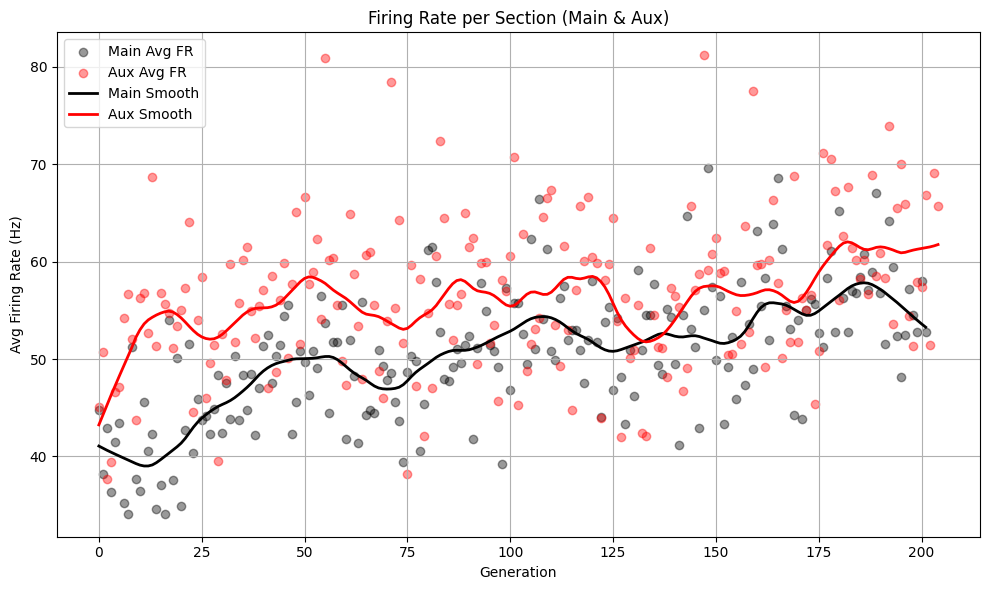

In [111]:

main_mean = FR_valid.mean(axis=1)
aux_mean  = np.array([fr.mean() for fr in FR_aux_blocks])

main_idx = np.arange(len(main_mean))
aux_idx  = np.arange(len(aux_mean))

main_smooth = lowess(main_mean, main_idx, frac=0.1)
aux_smooth  = lowess(aux_mean,  aux_idx,  frac=0.1)

plt.figure(figsize=(10,6))

plt.scatter(main_idx, main_mean, color='black', alpha=0.4, label='Main Avg FR')
plt.scatter(aux_idx,  aux_mean,  color='red', alpha=0.4, label='Aux Avg FR')

plt.plot(main_smooth[:,0], main_smooth[:,1], color='black', linewidth=2, label='Main Smooth')
plt.plot(aux_smooth[:,0],  aux_smooth[:,1],  color='red', linewidth=2, label='Aux Smooth')

plt.xlabel('Generation')
plt.ylabel('Avg Firing Rate (Hz)')
plt.title('Firing Rate per Section (Main & Aux)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [107]:

def compare_main_aux(FR_main_blocks, FR_aux_blocks):
    """
    FR_main_blocks : list of 1D np.arrays (each length 64)
    FR_aux_blocks  : list of 1D np.arrays (varying lengths)
    """
    # --- 1) Pool all trials' FRs ---
    all_main_rates = np.hstack(FR_main_blocks)      # shape = (n_main_blocks * 64,)
    all_aux_rates  = np.hstack(FR_aux_blocks)       # shape = (sum n_aux_trials,)

    # Mann–Whitney U (non-parametric)
    u_stat, p_mw = mannwhitneyu(all_main_rates,
                                all_aux_rates,
                                alternative='greater')
    # Independent t-test
    t_stat, p_t  = ttest_ind(all_main_rates,
                             all_aux_rates,
                             equal_var=False)

    print("=== Pooled Trial‐rate Comparison ===")
    print(f"  Main: mean={all_main_rates.mean():.2f}, n={all_main_rates.size}")
    print(f"  Aux : mean={all_aux_rates.mean():.2f}, n={all_aux_rates.size}")
    print(f"  Mann–Whitney U p-value: {p_mw:.3g}")
    print(f"  t-test p-value:        {p_t:.3g}\n")

    # --- 2) Compare per‐block slopes ---
    # Compute one slope per block: trial‐index vs FR
    slopes_main = []
    for fr in FR_main_blocks:
        x = np.arange(len(fr))
        slope, _, _, _, _ = linregress(x, fr)
        slopes_main.append(slope)

    slopes_aux = []
    for fr in FR_aux_blocks:
        x = np.arange(len(fr))
        slope, _, _, _, _ = linregress(x, fr)
        slopes_aux.append(slope)

    slopes_main = np.array(slopes_main)
    slopes_aux  = np.array(slopes_aux)

    # Stats on slopes
    u_slope, p_mw_slope = mannwhitneyu(slopes_main,
                                       slopes_aux,
                                       alternative='greater')
    t_slope, p_t_slope  = ttest_ind(slopes_main,
                                    slopes_aux,
                                    equal_var=False)

    print("=== Per-Block Slope Comparison ===")
    print(f"  Main slope: mean={slopes_main.mean():.2e}, n={slopes_main.size}")
    print(f"  Aux  slope: mean={slopes_aux.mean():.2e}, n={slopes_aux.size}")
    print(f"  Mann–Whitney U p-value: {p_mw_slope:.3g}")
    print(f"  t-test p-value:        {p_t_slope:.3g}")

    return {
        'pooled': {
            'mean_main': all_main_rates.mean(),
            'mean_aux': all_aux_rates.mean(),
            'p_mw': p_mw,
            'p_t': p_t
        },
        'slopes': {
            'mean_main': slopes_main.mean(),
            'mean_aux': slopes_aux.mean(),
            'p_mw': p_mw_slope,
            'p_t': p_t_slope
        }
    }



In [108]:
results = compare_main_aux(FR_main_blocks, FR_aux_blocks)


=== Pooled Trial‐rate Comparison ===
  Main: mean=50.60, n=12928
  Aux : mean=56.42, n=7528
  Mann–Whitney U p-value: 1
  t-test p-value:        2.34e-14

=== Per-Block Slope Comparison ===
  Main slope: mean=1.14e-02, n=202
  Aux  slope: mean=-1.36e-01, n=205
  Mann–Whitney U p-value: 0.00242
  t-test p-value:        0.00205
